# 06 — Statistical Comparison: Top 3 Configurations from Notebook 05


In notebook 05 we tested many GA configurations but only ran each one once. The problem with a single run is that the result depends heavily on the random seed — a configuration that looked best with one seed might perform worse on average.

To properly answer which configuration is actually better, we run each one **30 times** with different seeds and compare the distributions of results using a statistical test.

## Which configurations?

We take the top 3 configurations from notebook 05, ranked by their single-run RMSE at 200 generations. All 3 share the same base setup — only the mutation strategy is different:

| Rank (nb06) | Label | What differs | Single-run RMSE |
|---|---|---|---|
| 1st | **Config A** | `adaptive_vertex_jitter` mutation | 37.17 |
| 2nd | **Config B** | `vertex_jitter` mutation | 37.85 |
| 3rd | **Config C** | `multi` mutation + `local_search=5` | 38.79 |

Config A and B only differ in how mutation works. Config C adds a local search step — after each generation, it runs 5 iterations of hill-climbing on the best individuals to refine them further.

---
## 0. Imports

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.chdir(os.path.abspath(".."))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu
from tqdm.notebook import tqdm

from src.ga import run_ga
from src.fitness import load_target

%matplotlib inline
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "monospace"


## 1. Experiment Parameters

All parameters match notebook 05 comparison setup (pop=100, 200 generations) so results are directly comparable. The only difference is we run 30 times instead of once.

In [ ]:
N_RUNS      = 30    
GENERATIONS = 200  
POP_SIZE    = 100   
ALPHA       = 0.05  

target = load_target()
print(f"Target image: {target.shape}")
print(f"Plan: {N_RUNS} runs × 3 configs × {GENERATIONS} generations")
print(f"Total GA calls: {N_RUNS * 3}")

Target image: (400, 300, 3)
Plan: 30 runs × 3 configs × 200 generations
Total GA calls: 90


## 2. Configuration Definitions

The shared base captures all the best settings found in notebook 05. We only vary the mutation strategy so that any performance difference can be attributed directly to that choice.

In [17]:
_BASE = dict(
    pop_size         = POP_SIZE,
    generations      = GENERATIONS,
    selection_method = "rank",
    crossover_method = "uniform",
    crossover_rate   = 0.8,
    mutation_rate    = 0.05,
    sigma            = 10.0,
    elite_size       = 2,
    fast_fitness     = True,
)

# Config A: adaptive_vertex_jitter
# Best single-run RMSE in notebook 05: 37.17
# Mutation adapts step-size based on fitness landscape
CONFIG_A = {**_BASE, "mutation_method": "adaptive_vertex_jitter"}

# Config B: vertex_jitter
# 2nd best single-run RMSE in notebook 05: 37.85
# Classic vertex-level Gaussian perturbation
CONFIG_B = {**_BASE, "mutation_method": "vertex_jitter"}

# Config C: multi mutation + local search (5 iters)
# 3rd best in notebook 05: 38.79
# GA + local search
CONFIG_C = {**_BASE, "mutation_method": "multi", "local_search_iterations": 5}

CONFIGS = {
    "A — adaptive_vertex_jitter": CONFIG_A,
    "B — vertex_jitter": CONFIG_B,
    "C — multi + local_search=5": CONFIG_C,
}

COLORS = {
    "A — adaptive_vertex_jitter":"#2196F3",
    "B — vertex_jitter": "#FF5722",  
    "C — multi + local_search=5":"#4CAF50",  
}

## 3. Run the Experiment

Each config runs 30 times with deterministic seeds (`seed = i`), ensuring runs are independent and reproducible. We use `joblib` to run them in parallel across CPU cores — same 90 total runs, just faster.

We store:
- `histories`: best fitness at every generation for each run → shape `(30, 200)`
- `final_best`: final generation best fitness per run → shape `(30,)` — this is what the statistical test uses

In [ ]:
def run_experiment(config: dict, label: str, n_runs: int, target_image) -> dict:
    """
    Run `n_runs` independent GA executions with the given config.
    Seeds are deterministic: run_i uses seed = i 

    Returns
    -------
    dict:
        histories   : np.ndarray (n_runs, generations) — best fitness per gen
        final_best  : np.ndarray (n_runs,)             — final generation best
        elapsed_sec : float
    """
    n_gen = config["generations"]
    histories  = np.zeros((n_runs, n_gen))
    final_best = np.zeros(n_runs)

    t0 = time.time()
    for i in tqdm(range(n_runs), desc=label):
        seed = i 
        _, best_fit, history = run_ga(
            target_image = target_image,
            seed         = seed,
            **config
        )
        # history is a dict with 'best_fitness' list, one value per generation
        hist_arr = np.array(history["best_fitness"])[:n_gen]
        histories[i, :len(hist_arr)] = hist_arr
        final_best[i] = best_fit

    elapsed = time.time() - t0
    print(f"{label}  →  mean RMSE={final_best.mean():.4f} ± {final_best.std():.4f}  "
          f"[{elapsed/60:.1f} min]")
    return {"histories": histories, "final_best": final_best, "elapsed_sec": elapsed}

In [ ]:
results_A = run_experiment(CONFIG_A, "A — adaptive_vertex_jitter", N_RUNS, target)

A — adaptive_vertex_jitter:   0%|          | 0/30 [00:00<?, ?it/s]

Generation 1/200 | Best: 66.6614 | Avg: 74.5536
Generation 2/200 | Best: 64.8744 | Avg: 72.8414
Generation 3/200 | Best: 64.3677 | Avg: 70.5454
Generation 4/200 | Best: 62.8781 | Avg: 69.0563
Generation 5/200 | Best: 62.8781 | Avg: 67.7427
Generation 6/200 | Best: 61.6553 | Avg: 66.8120
Generation 7/200 | Best: 59.5562 | Avg: 65.7857
Generation 8/200 | Best: 59.4935 | Avg: 64.8604
Generation 9/200 | Best: 59.4935 | Avg: 64.5308
Generation 10/200 | Best: 59.3064 | Avg: 63.7057
Generation 11/200 | Best: 58.9949 | Avg: 63.1937
Generation 12/200 | Best: 56.3818 | Avg: 62.4702
Generation 13/200 | Best: 56.3818 | Avg: 61.9815
Generation 14/200 | Best: 56.0697 | Avg: 60.6996
Generation 15/200 | Best: 55.2637 | Avg: 59.7808
Generation 16/200 | Best: 55.2637 | Avg: 58.8908
Generation 17/200 | Best: 55.0468 | Avg: 58.2480
Generation 18/200 | Best: 54.2198 | Avg: 57.5188
Generation 19/200 | Best: 53.9432 | Avg: 57.1146
Generation 20/200 | Best: 53.9432 | Avg: 56.5924
Generation 21/200 | Best: 53.

In [ ]:
results_B = run_experiment(CONFIG_B, "B — vertex_jitter", N_RUNS, target)

B — vertex_jitter:   0%|          | 0/30 [00:00<?, ?it/s]

Generation 1/200 | Best: 66.6614 | Avg: 74.5536
Generation 2/200 | Best: 64.8744 | Avg: 72.8414
Generation 3/200 | Best: 64.3705 | Avg: 70.5461
Generation 4/200 | Best: 62.8781 | Avg: 69.0915
Generation 5/200 | Best: 62.4820 | Avg: 67.7678
Generation 6/200 | Best: 62.2845 | Avg: 66.5108
Generation 7/200 | Best: 62.1254 | Avg: 65.7140
Generation 8/200 | Best: 59.8070 | Avg: 65.0959
Generation 9/200 | Best: 59.8070 | Avg: 64.5049
Generation 10/200 | Best: 59.8070 | Avg: 63.4881
Generation 11/200 | Best: 58.6157 | Avg: 62.7119
Generation 12/200 | Best: 58.6157 | Avg: 62.1123
Generation 13/200 | Best: 57.9657 | Avg: 61.7798
Generation 14/200 | Best: 57.3553 | Avg: 60.8531
Generation 15/200 | Best: 56.7360 | Avg: 60.0639
Generation 16/200 | Best: 56.7360 | Avg: 59.3205
Generation 17/200 | Best: 55.2252 | Avg: 58.8909
Generation 18/200 | Best: 55.2252 | Avg: 58.2380
Generation 19/200 | Best: 54.8498 | Avg: 57.6662
Generation 20/200 | Best: 54.8498 | Avg: 57.1746
Generation 21/200 | Best: 53.

In [ ]:
results_C = run_experiment(CONFIG_C, "C — multi + local_search=5", N_RUNS, target)

C — multi + local_search=5:   0%|          | 0/30 [00:00<?, ?it/s]

Generation 1/200 | Best: 66.6614 | Avg: 74.5536
Generation 2/200 | Best: 65.7996 | Avg: 72.5322
Generation 3/200 | Best: 65.2763 | Avg: 70.6851
Generation 4/200 | Best: 65.0107 | Avg: 69.5933
Generation 5/200 | Best: 64.0030 | Avg: 68.4787
Generation 6/200 | Best: 62.0939 | Avg: 67.1615
Generation 7/200 | Best: 62.0196 | Avg: 65.8169
Generation 8/200 | Best: 60.8113 | Avg: 64.9748
Generation 9/200 | Best: 60.4728 | Avg: 63.9225
Generation 10/200 | Best: 59.8849 | Avg: 63.1872
Generation 11/200 | Best: 58.1783 | Avg: 62.3224
Generation 12/200 | Best: 58.0549 | Avg: 61.3782
Generation 13/200 | Best: 57.2455 | Avg: 60.6553
Generation 14/200 | Best: 57.1504 | Avg: 60.0904
Generation 15/200 | Best: 56.5387 | Avg: 59.2376
Generation 16/200 | Best: 54.4539 | Avg: 58.6867
Generation 17/200 | Best: 54.4085 | Avg: 58.1512
Generation 18/200 | Best: 54.2546 | Avg: 57.5084
Generation 19/200 | Best: 53.9055 | Avg: 56.7623
Generation 20/200 | Best: 53.8679 | Avg: 56.3364
Generation 21/200 | Best: 53.

## 4. Compute Average Best Fitness (ABF)

$$\text{ABF}(g) = \frac{1}{k}\sum_{i=1}^{k} \text{bestFitness}_i(g)$$

To compare the convergence behaviour of the three configurations across multiple independent runs, we compute the Average Best Fitness (ABF) at each generation. Since each run is initialised with a different random seed, the best fitness trajectory varies between runs. Averaging across all 30 runs at each generation smooths out this stochastic variation and produces a single representative convergence curve per configuration. Alongside the ABF, we compute the standard deviation across runs at each generation, which quantifies how consistent each configuration is — a low standard deviation indicates that the configuration performs reliably regardless of the random initialisation, while a high standard deviation suggests sensitivity to the initial conditions. 

In [8]:
all_results = {
    "A — adaptive_vertex_jitter":  results_A,
    "B — vertex_jitter":           results_B,
    "C — multi + local_search=5": results_C,
}

abf  = {k: v["histories"].mean(axis=0) for k, v in all_results.items()}
std  = {k: v["histories"].std(axis=0)  for k, v in all_results.items()}
gens = np.arange(1, GENERATIONS + 1)

print("ABF at final generation:")
for name in all_results:
    print(f"  {name:35s} {abf[name][-1]:.4f} ± {std[name][-1]:.4f}")

ABF at final generation:
  A — adaptive_vertex_jitter          37.5315 ± 1.0840
  B — vertex_jitter                   37.7799 ± 0.9543
  C — multi + local_search=5          35.2741 ± 0.7446


## 5. Pairwise Statistical Tests

We compare every pair of configs on their **final-generation RMSE values** (the 30 numbers collected at generation 200).

**Why Mann-Whitney U?** It ranks all 60 values together and checks whether one config's values cluster at the better end. No assumption about the shape of the distribution — correct for GA fitness which is rarely Gaussian.

**Why Bonferroni correction?** We run 3 pairwise tests. If each used α=0.05 independently, the probability of at least one false positive would be ~14%. Dividing α by the number of tests (α/3 = 0.0167) keeps the overall false-positive rate at 5%.

**Null hypothesis H₀**: the two configs produce the same fitness distribution. If p < 0.0167 we reject H₀ — the difference is statistically significant.

In [20]:
config_names = list(all_results.keys())
n_pairs = len(list(combinations(config_names, 2)))
alpha_bonf = ALPHA / n_pairs

test_results = {}
for name_i, name_j in combinations(config_names, 2):
    x = all_results[name_i]["final_best"]
    y = all_results[name_j]["final_best"]
    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    significant = p < alpha_bonf

    if x.mean() < y.mean():
        better = name_i
    elif y.mean() < x.mean():
        better = name_j
    else:
        better = "tie"

    test_results[(name_i, name_j)] = {"stat": stat, "p": p, "significant": significant, "better": better}

    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.6f}"
    verdict = "SIGNIFICANT" if significant else "not significant"
    print(f"{name_i} vs {name_j}")
    print(f"  U={stat:.1f}  p={p_str}  {verdict}")
    if significant:
        print(f"  → {better} is statistically better")
    print(f"  Means: {x.mean():.4f} vs {y.mean():.4f}\n")

A — adaptive_vertex_jitter vs B — vertex_jitter
  U=375.0  p=0.270705  not significant
  Means: 37.5315 vs 37.7799

A — adaptive_vertex_jitter vs C — multi + local_search=5
  U=873.0  p=4.20e-10  SIGNIFICANT
  → C — multi + local_search=5 is statistically better
  Means: 37.5315 vs 35.2741

B — vertex_jitter vs C — multi + local_search=5
  U=887.0  p=1.09e-10  SIGNIFICANT
  → C — multi + local_search=5 is statistically better
  Means: 37.7799 vs 35.2741




## 6. Results — Summary Table

Sorted by mean RMSE (lower is better). This table captures both the average quality and the consistency (std) of each config across 30 independent runs.

In [21]:
df = pd.DataFrame({
    name: {
        "Mean RMSE": round(v["final_best"].mean(), 4),
        "Std RMSE":  round(v["final_best"].std(),  4),
        "Min RMSE":  round(v["final_best"].min(),  4),
        "Max RMSE":  round(v["final_best"].max(),  4),
        "Median":    round(float(np.median(v["final_best"])), 4),
    }
    for name, v in all_results.items()
}).T.sort_values("Mean RMSE")

df

,Mean RMSE,Std RMSE,Min RMSE,Max RMSE,Median
C — multi + local_search=5,35.2741,0.7446,33.7230,36.9746,35.2391
A — adaptive_vertex_jitter,37.5315,1.0840,35.9528,39.8758,37.2944
B — vertex_jitter,37.7799,0.9543,35.8271,39.7880,37.4564


## 8. Visualisation

Three panels showing the results of the comparison:
- **Left**: average convergence curves with ±1 std shaded bands
- **Centre**: error bars at 8 points across the run
- **Right**: boxplots with individual run dots — full distribution of final RMSE across all 30 runs

C:\Users\ashul\AppData\Local\Temp\ipykernel_17512\1915283970.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_list, labels=["A", "B", "C"], patch_artist=True,


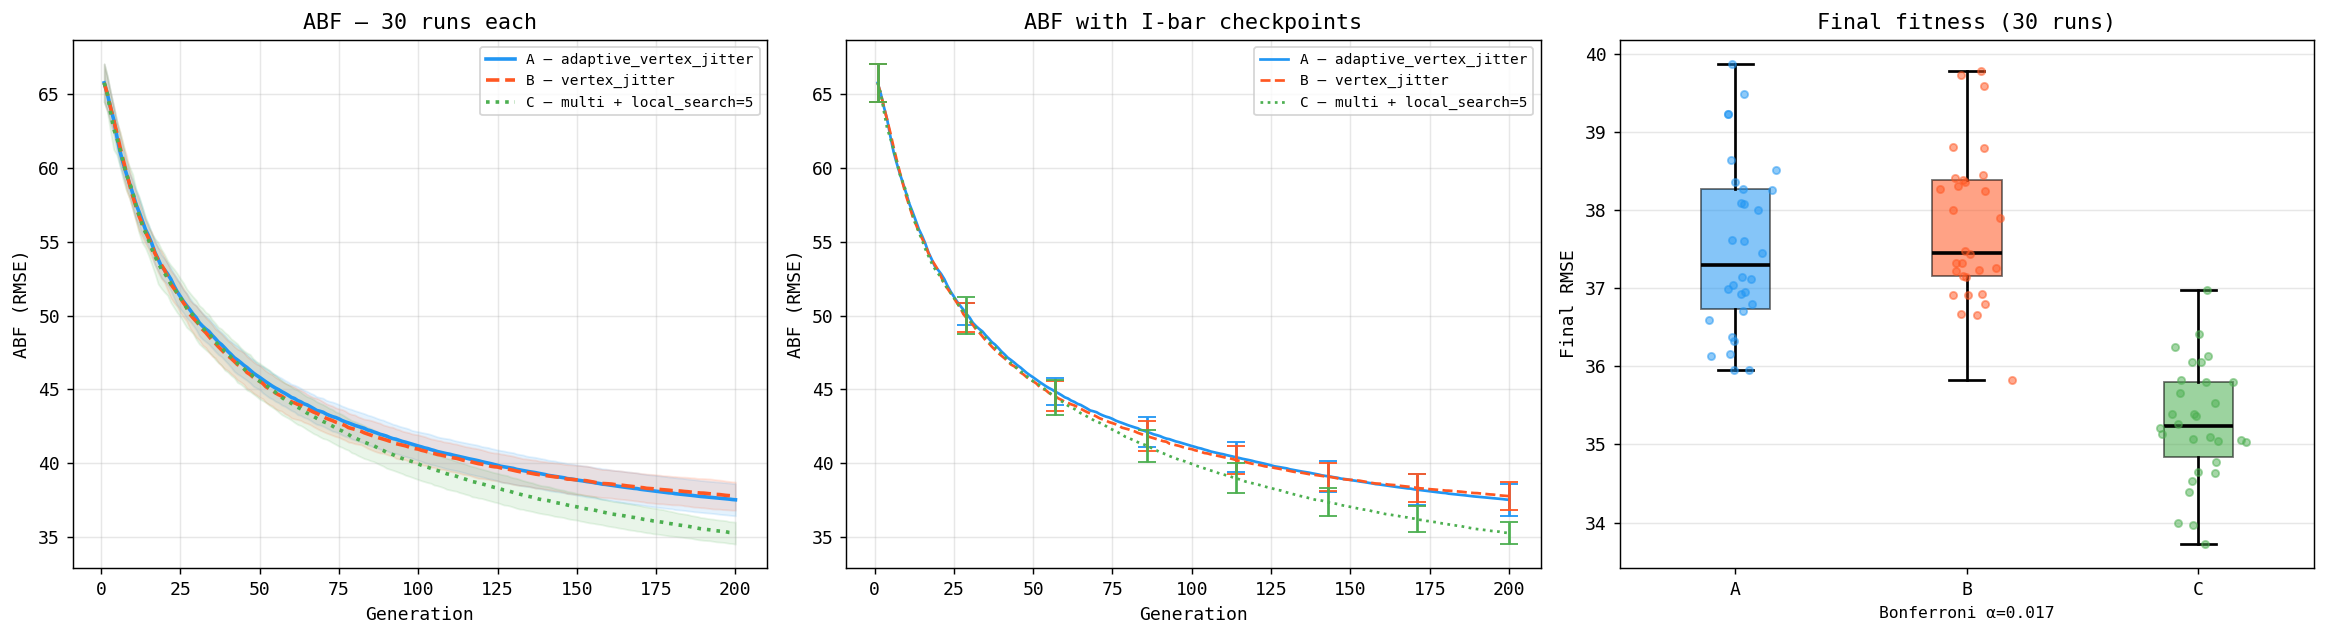

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
checkpoints = np.linspace(0, GENERATIONS - 1, 8, dtype=int)

# ABF curves + std bands
for (name, color), ls in zip(COLORS.items(), linestyles):
    ax1.plot(gens, abf[name], color=color, lw=2, ls=ls, label=name)
    ax1.fill_between(gens, abf[name]-std[name], abf[name]+std[name], alpha=0.12, color=color)
ax1.set(xlabel="Generation", ylabel="ABF (RMSE)", title=f"ABF — {N_RUNS} runs each")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# I-bar error bars
for (name, color), ls in zip(COLORS.items(), linestyles):
    ax2.plot(gens, abf[name], color=color, lw=1.5, ls=ls, label=name)
    ax2.errorbar(gens[checkpoints], abf[name][checkpoints], yerr=std[name][checkpoints],
                 fmt="none", ecolor=color, capsize=5, elinewidth=1.5)
ax2.set(xlabel="Generation", ylabel="ABF (RMSE)", title="ABF with I-bar checkpoints")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Boxplots + jittered dots
data_list  = [all_results[n]["final_best"] for n in config_names]
color_list = [COLORS[n] for n in config_names]
bp = ax3.boxplot(data_list, labels=["A", "B", "C"], patch_artist=True,
                 medianprops=dict(color="black", lw=2),
                 whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5))
for patch, color in zip(bp["boxes"], color_list):
    patch.set_facecolor(color); patch.set_alpha(0.55)
for i, (data, color) in enumerate(zip(data_list, color_list)):
    ax3.scatter(np.random.normal(i+1, 0.07, len(data)), data, alpha=0.5, color=color, s=16, zorder=3)
ax3.set(ylabel="Final RMSE", title=f"Final fitness ({N_RUNS} runs)")
ax3.set_xlabel(f"Bonferroni α={alpha_bonf:.3f}", fontsize=9)
ax3.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

The plots perfectly support the statistical findings. Config C (GA with local search) is the clear winner — not only does it achieve better average fitness, it does so more consistently. The fact that A and B are visually and statistically identical suggests the adaptive step-size in Config A provides no real benefit over standard vertex jitter at this budget of 200 generations.


## 9. Conclusions
- Config C is the clear winner despite being ranked 3rd in notebook 05. This demonstrates that single-run results are unreliable and can be misleading.
- Local search makes a real difference. Adding 5 hill-climbing iterations per generation to the multi mutation gave a consistent ~2.3 RMSE improvement over the pure mutation variants, and with lower variance (std=0.74 vs 1.08), meaning it's also more reliable.
- daptive_vertex_jitter provides no advantage over plain vertex_jitter at this generation budget. Despite its more sophisticated adaptive mechanism, the two are statistically indistinguishable — the adaptation likely needs more generations to show its benefit.
